In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("Dataset_Day14.csv")

# Check missing values
print(df.isnull().sum())

# Features for clustering
X = df[[
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]]

# Scale the data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data scaling completed")

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
Data scaling completed


In [2]:
from sklearn.cluster import DBSCAN

# Create DBSCAN model
model = DBSCAN(eps=0.8, min_samples=4)

# Fit model
clusters = model.fit_predict(X_scaled)

# Add cluster labels to dataframe
df["Cluster"] = clusters

# Display first rows
print(df.head())

# Count species in each cluster
table = pd.crosstab(df["Cluster"], df["Species"])

print(table)

# Percentage distribution
percent_table = pd.crosstab(
    df["Cluster"],
    df["Species"],
    normalize="index"
) * 100

print(percent_table)

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0   1            5.1           3.5            1.4           0.2  Iris-setosa   
1   2            4.9           3.0            1.4           0.2  Iris-setosa   
2   3            4.7           3.2            1.3           0.2  Iris-setosa   
3   4            4.6           3.1            1.5           0.2  Iris-setosa   
4   5            5.0           3.6            1.4           0.2  Iris-setosa   

   Cluster  
0        0  
1        0  
2        0  
3        0  
4        0  
Species  Iris-setosa  Iris-versicolor  Iris-virginica
Cluster                                              
-1                 1                0               3
 0                49                0               0
 1                 0               50              47
Species  Iris-setosa  Iris-versicolor  Iris-virginica
Cluster                                              
-1              25.0         0.000000       75.000000
 0       

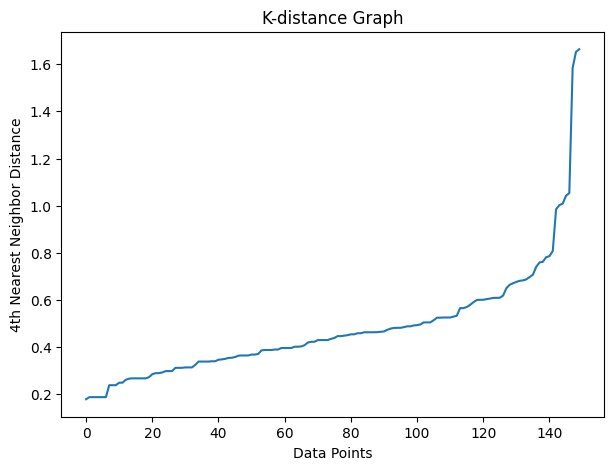

In [3]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# Find nearest neighbours
neighbors = NearestNeighbors(n_neighbors=4)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances
distances = np.sort(distances[:, 3])

# Plot graph
plt.figure(figsize=(7,5))

plt.plot(distances)

plt.xlabel("Data Points")
plt.ylabel("4th Nearest Neighbor Distance")

plt.title("K-distance Graph")

plt.show()

In [5]:
from sklearn.metrics import silhouette_score

scores = []

# Try different values of min_samples
for m in range(2,11):

    model = DBSCAN(
        eps=0.8,
        min_samples=m
    )

    labels = model.fit_predict(X_scaled)

    # Ignore if only one cluster exists
    if len(set(labels)) > 1:

        score = silhouette_score(X_scaled, labels)

        scores.append(score)

        print("min_samples =", m,
              "Silhouette Score =", score)

best_min = 2 + scores.index(max(scores))

print("Best min_samples =", best_min)

min_samples = 2 Silhouette Score = 0.48612383626680866
min_samples = 3 Silhouette Score = 0.5205966153011559
min_samples = 4 Silhouette Score = 0.5205966153011559
min_samples = 5 Silhouette Score = 0.5205966153011559
min_samples = 6 Silhouette Score = 0.5205966153011559
min_samples = 7 Silhouette Score = 0.5215635176967445
min_samples = 8 Silhouette Score = 0.5097793673832155
min_samples = 9 Silhouette Score = 0.5097793673832155
min_samples = 10 Silhouette Score = 0.5097793673832155
Best min_samples = 7


In [6]:
# Final DBSCAN model
model = DBSCAN(
    eps=0.8,
    min_samples=4
)

labels = model.fit_predict(X_scaled)

df["Cluster"] = labels

# Outliers have label -1
outliers = df[df["Cluster"] == -1]

print("Number of outliers =", len(outliers))

print(outliers)

Number of outliers = 4
      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
41    42            4.5           2.3            1.3           0.3   
109  110            7.2           3.6            6.1           2.5   
117  118            7.7           3.8            6.7           2.2   
131  132            7.9           3.8            6.4           2.0   

            Species  Cluster  
41      Iris-setosa       -1  
109  Iris-virginica       -1  
117  Iris-virginica       -1  
131  Iris-virginica       -1  
